Импорт необходимых модулей:

In [156]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

import platform
import subprocess

### Генерируем точки + строим графики и изображения

In [157]:
#total_points_sqrt = 3163
total_points_sqrt = 100
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10000


Билдим проект через cmake

In [158]:
subprocess.run(['cmake', '.', '-B', 'bin/', '-G', 'Ninja', '-D', 'CMAKE_BUILD_TYPE=Release'])
subprocess.run(['cmake', '--build', 'bin/'])

-- Configuring done
-- Generating done
-- Build files have been written to: /home/joel/Development/practice/nikulin/cpp/2_pi_monte_carlo/histogram2/bin
ninja: no work to do.


CompletedProcess(args=['cmake', '--build', 'bin/'], returncode=0)

Запускаем генерацию точек

In [159]:
if platform.system() == 'Windows':
    out = subprocess.check_output( "bin/ResearchGenerators.exe --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "bin/ResearchGenerators.exe --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "bin/ResearchGenerators.exe --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "bin/ResearchGenerators.exe --rand " + str(total_points), shell=True, text=True )
    print(out)
else:
    out = subprocess.check_output( "./bin/ResearchGenerators --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/ResearchGenerators --rand " + str(total_points), shell=True, text=True )
    print(out)

Elapsed time for generator: "xs64"; Total values: 10000	 --- 5016 microseconds

Elapsed time for generator: "xs1024"; Total values: 10000	 --- 4655 microseconds

Elapsed time for generator: "mt19937"; Total values: 10000	 --- 4098 microseconds

Elapsed time for generator: "rand"; Total values: 10000	 --- 5337 microseconds



Подгружаем сгенерированные выборки:

In [160]:
x64      = pd.read_csv("xs64.csv")
x1024    = pd.read_csv("xs1024.csv")
mt19937  = pd.read_csv("mt19937.csv")
rand     = pd.read_csv("rand.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [161]:
x64.head()

,randoms
0,0.334649
1,0.660280
2,0.996595
3,0.924853
4,0.131828


Описательная статистика:

In [162]:
x64['randoms'].describe()

count    10000.000000
mean         0.498226
std          0.287927
min          0.000155
25%          0.251038
50%          0.496621
75%          0.746237
max          0.999985
Name: randoms, dtype: float64

Строим гистограммы:

[Text(0.5, 1.0, 'XORShift64 --- 10000 values')]

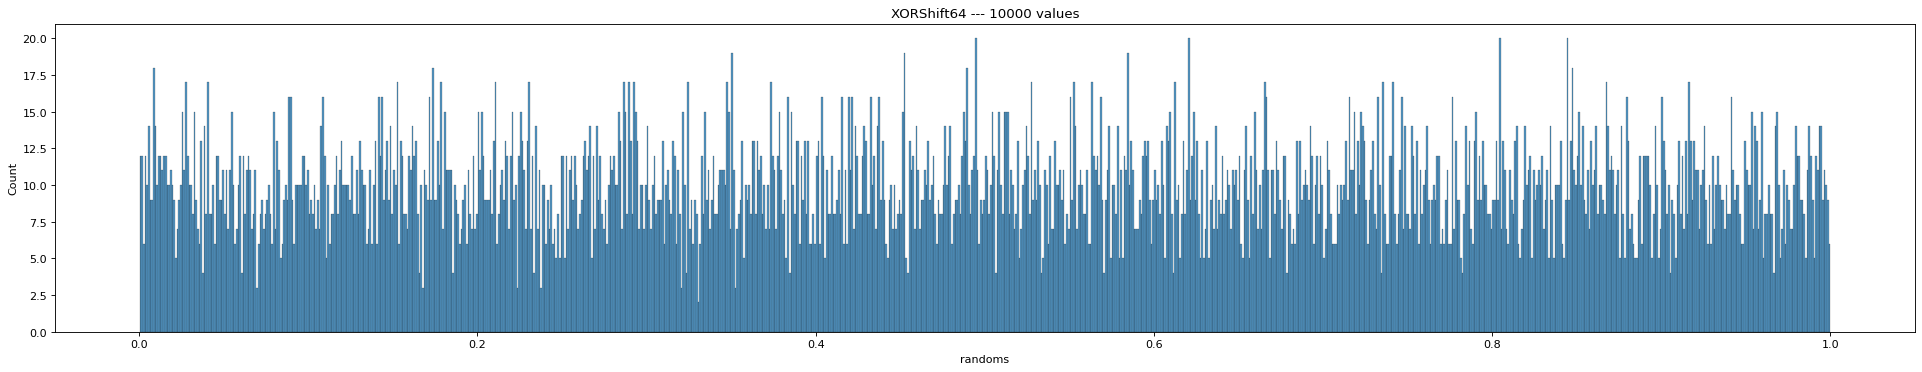

In [163]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=1000).set(title='XORShift64 --- ' + str(total_points) + ' values')
# plt.ylim(bottom=9500, top=10550)

In [164]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [165]:
data.shape

(10000, 1)

In [166]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[ 85 168 254 ...  95 190   9]
 [ 30 187 154 ...  45 152 157]
 [233 246   0 ... 208 128 124]
 ...
 [239 196 119 ... 249  66 107]
 [ 46  60 149 ... 171 239  31]
 [208 201 220 ...  67  44 192]]


In [167]:
data.shape

(100, 100)

In [168]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

[Text(0.5, 1.0, 'XORShift1024 --- 10000 values')]

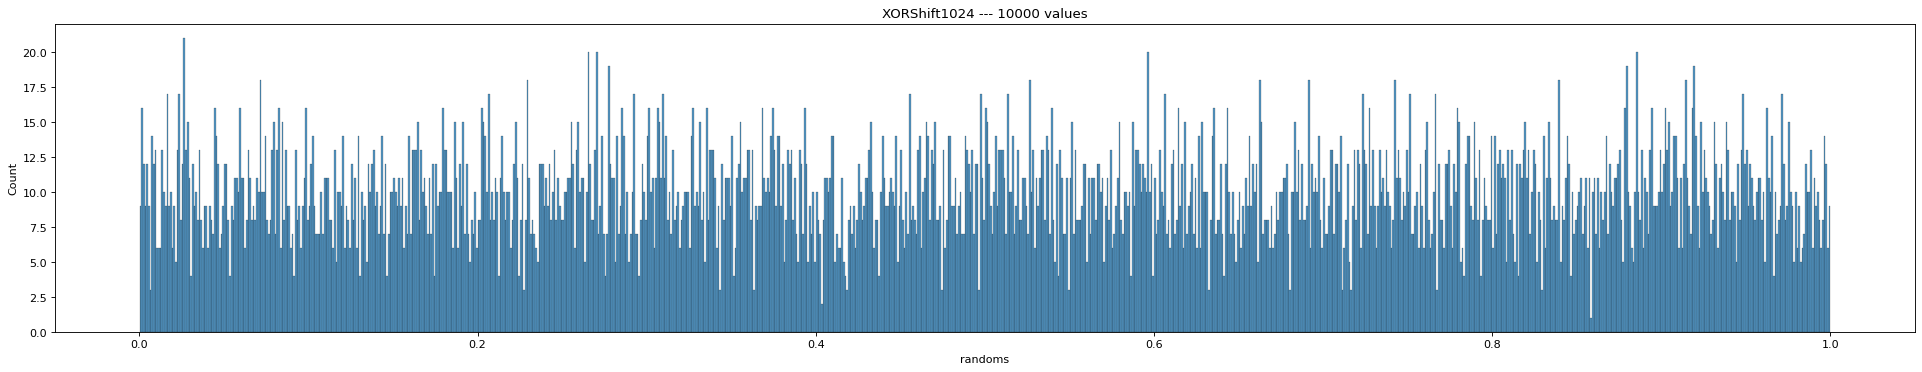

In [169]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=1000).set(title='XORShift1024 --- ' + str(total_points) + ' values')
# plt.ylim(bottom=9500, top=10550)

In [170]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [171]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

[Text(0.5, 1.0, 'CPP STD MT19937 --- 10000 values')]

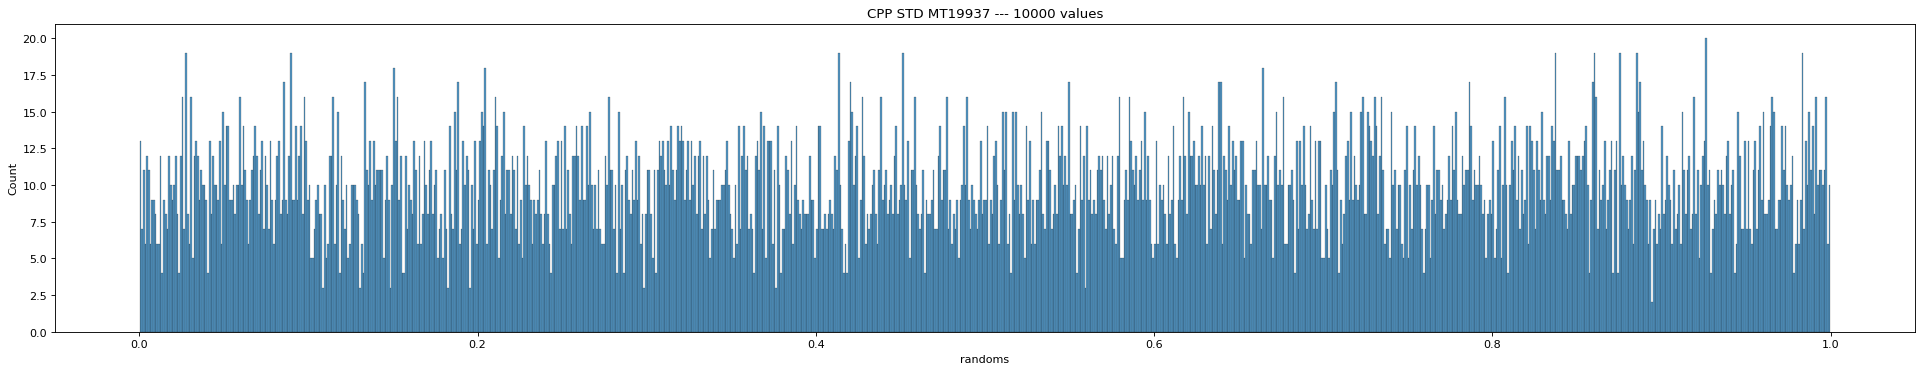

In [172]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=1000).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')
# plt.ylim(bottom=9500, top=10550)

In [173]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [174]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

[Text(0.5, 1.0, 'C stdlib.h rand() --- 10000 values')]

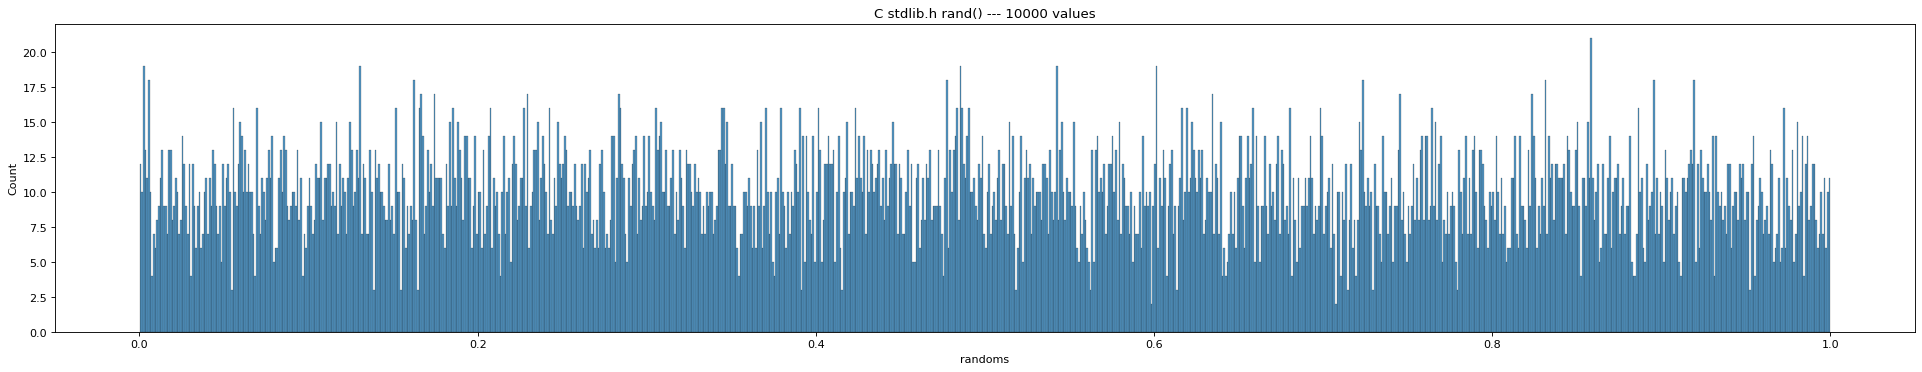

In [175]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand, x="randoms", bins=1000).set(title='C stdlib.h rand() --- ' + str(total_points) + ' values')
# plt.ylim(bottom=9500, top=10550)

In [176]:
data = 255 * np.array(rand)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [177]:
img = Image.fromarray(data, 'L')
img.save('CSTDLibRand_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [178]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(generated_values, type='by-sum'):
    size = len(generated_values)

    # массив ожидаемых значений [0..1)
    range_step = 1.0 / size
    expected_values = np.arange(start=0, stop=1, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1)

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    # по сумме
    if type == 'by-sum':

        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    # по элементно
    elif type == 'by-element':

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        error = 1 - good_elements / size
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {size}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [179]:
type = 'by-element'

Метрика качества для XorShift64:

In [180]:
quality = get_quality_of_values(x64, type)
print(f'XorShift64 Quality: {quality}')

Expected values: [0.000e+00 1.000e-04 2.000e-04 ... 9.997e-01 9.998e-01 9.999e-01]
Generated values: [[0.334649]
 [0.66028 ]
 [0.996595]
 ...
 [0.263281]
 [0.173474]
 [0.755011]]
Good elements: 6333
Total generated values: 10000
Error: 0.3667
XorShift64 Quality: 0.6333


Метрика качества для XorShift1024:

In [181]:
quality = get_quality_of_values(x1024, type)
print(f'XorShift1024 Quality: {quality}')

Expected values: [0.000e+00 1.000e-04 2.000e-04 ... 9.997e-01 9.998e-01 9.999e-01]
Generated values: [[0.526024 ]
 [0.14226  ]
 [0.371616 ]
 ...
 [0.735655 ]
 [0.867179 ]
 [0.0444456]]
Good elements: 6343
Total generated values: 10000
Error: 0.3657
XorShift1024 Quality: 0.6343


Метрика качества для MT19937:

In [182]:
quality = get_quality_of_values(mt19937, type)
print(f'MT19937 Quality: {quality}')

Expected values: [0.000e+00 1.000e-04 2.000e-04 ... 9.997e-01 9.998e-01 9.999e-01]
Generated values: [[0.479748]
 [0.774217]
 [0.966813]
 ...
 [0.501394]
 [0.396482]
 [0.669519]]
Good elements: 6317
Total generated values: 10000
Error: 0.36829999999999996
MT19937 Quality: 0.6317


In [183]:
quality = get_quality_of_values(rand, type)
print(f'C stdlib.h rand() Quality: {quality}')

Expected values: [0.000e+00 1.000e-04 2.000e-04 ... 9.997e-01 9.998e-01 9.999e-01]
Generated values: [[0.687013]
 [0.143302]
 [0.248986]
 ...
 [0.579496]
 [0.620334]
 [0.308887]]
Good elements: 6335
Total generated values: 10000
Error: 0.36650000000000005
C stdlib.h rand() Quality: 0.6335
